# Bank Telemarketing Prediction Models

This notebook trains three machine learning models on the bank-full-transformed dataset to predict the target variable 'y' (whether a customer will subscribe to a term deposit).

## 1. Load Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve, confusion_matrix
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

## 2. Load and Inspect Dataset

In [2]:
# Load the dataset
df = pd.read_csv('data_firsts_final.csv')

# Display basic information
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nSummary statistics:")
print(df.describe())
print("\nClass distribution for target 'y':")
print(df['y'].value_counts())
print("\nClass balance:")
print(df['y'].value_counts(normalize=True))

Dataset shape: (45211, 33)

First 5 rows:
   day  pdays  previous poutcome  age_group_young_adult  age_group_adult  \
0    5     -1         0  unknown                  False            False   
1    5     -1         0  unknown                  False             True   
2    5     -1         0  unknown                   True            False   
3    5     -1         0  unknown                  False             True   
4    5     -1         0  unknown                   True            False   

   age_group_middle_aged  age_group_senior  job_blue-collar  job_entrepreneur  \
0                   True             False            False             False   
1                  False             False            False             False   
2                  False             False            False              True   
3                  False             False             True             False   
4                  False             False            False             False   

   ...  educat

## 3. Preprocess Features and Target

In [3]:
# Separate features and target
X = df.drop('y', axis=1)
y = df['y'].astype(int)  # Convert to int for consistent class labels

# Convert boolean columns to int
bool_cols = X.select_dtypes(include=['bool']).columns
X[bool_cols] = X[bool_cols].astype(int)

# Encode categorical columns
cat_cols = X.select_dtypes(include=['object']).columns
if len(cat_cols) > 0:
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Training target distribution:")
print(y_train.value_counts(normalize=True))
print("Test target distribution:")
print(y_test.value_counts(normalize=True))

Training set shape: (36168, 34)
Test set shape: (9043, 34)
Training target distribution:
y
0    0.883018
1    0.116982
Name: proportion, dtype: float64
Test target distribution:
y
0    0.883003
1    0.116997
Name: proportion, dtype: float64


C:\Users\Lenna\AppData\Local\Temp\ipykernel_15784\3970498905.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object']).columns


## 4. Train Logistic Regression

In [4]:
# Train Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# Predict
lr_pred = lr_model.predict(X_test)
lr_pred_proba = lr_model.predict_proba(X_test)[:, 1]

# Evaluate
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_roc_auc = roc_auc_score(y_test, lr_pred_proba)
lr_report = classification_report(y_test, lr_pred, output_dict=True)

print("Logistic Regression Results:")
print(f"Accuracy: {lr_accuracy:.4f}")
print(f"ROC AUC: {lr_roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

Logistic Regression Results:
Accuracy: 0.8937
ROC AUC: 0.7581

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      7985
           1       0.69      0.17      0.27      1058

    accuracy                           0.89      9043
   macro avg       0.79      0.58      0.61      9043
weighted avg       0.87      0.89      0.86      9043



c:\Users\Lenna\Documents\Repos\bank-telemarketing-prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 5. Train XGBoost

In [5]:
# Train XGBoost
xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Predict
xgb_pred = xgb_model.predict(X_test)
xgb_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_roc_auc = roc_auc_score(y_test, xgb_pred_proba)
xgb_report = classification_report(y_test, xgb_pred, output_dict=True)

print("XGBoost Results:")
print(f"Accuracy: {xgb_accuracy:.4f}")
print(f"ROC AUC: {xgb_roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

# Feature importance
xgb_feature_importance = xgb_model.feature_importances_

XGBoost Results:
Accuracy: 0.8923
ROC AUC: 0.7888

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7985
           1       0.60      0.25      0.35      1058

    accuracy                           0.89      9043
   macro avg       0.75      0.61      0.64      9043
weighted avg       0.87      0.89      0.87      9043



## 6. Train Random Forest

In [6]:
# Train Random Forest
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

# Predict
rf_pred = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Evaluate
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_pred_proba)
rf_report = classification_report(y_test, rf_pred, output_dict=True)

print("Random Forest Results:")
print(f"Accuracy: {rf_accuracy:.4f}")
print(f"ROC AUC: {rf_roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

# Feature importance
rf_feature_importance = rf_model.feature_importances_

Random Forest Results:
Accuracy: 0.8916
ROC AUC: 0.7782

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      7985
           1       0.61      0.20      0.30      1058

    accuracy                           0.89      9043
   macro avg       0.76      0.59      0.62      9043
weighted avg       0.87      0.89      0.87      9043



## 7. Evaluate Models

Models Comparison:
                 Model  Accuracy   ROC AUC  Precision (Class 1)  \
0  Logistic Regression  0.893730  0.758119             0.685824   
1              XGBoost  0.892292  0.788751             0.596330   
2        Random Forest  0.891629  0.778218             0.612717   

   Recall (Class 1)  F1-Score (Class 1)  
0          0.169187            0.271418  
1          0.245747            0.348059  
2          0.200378            0.301994  


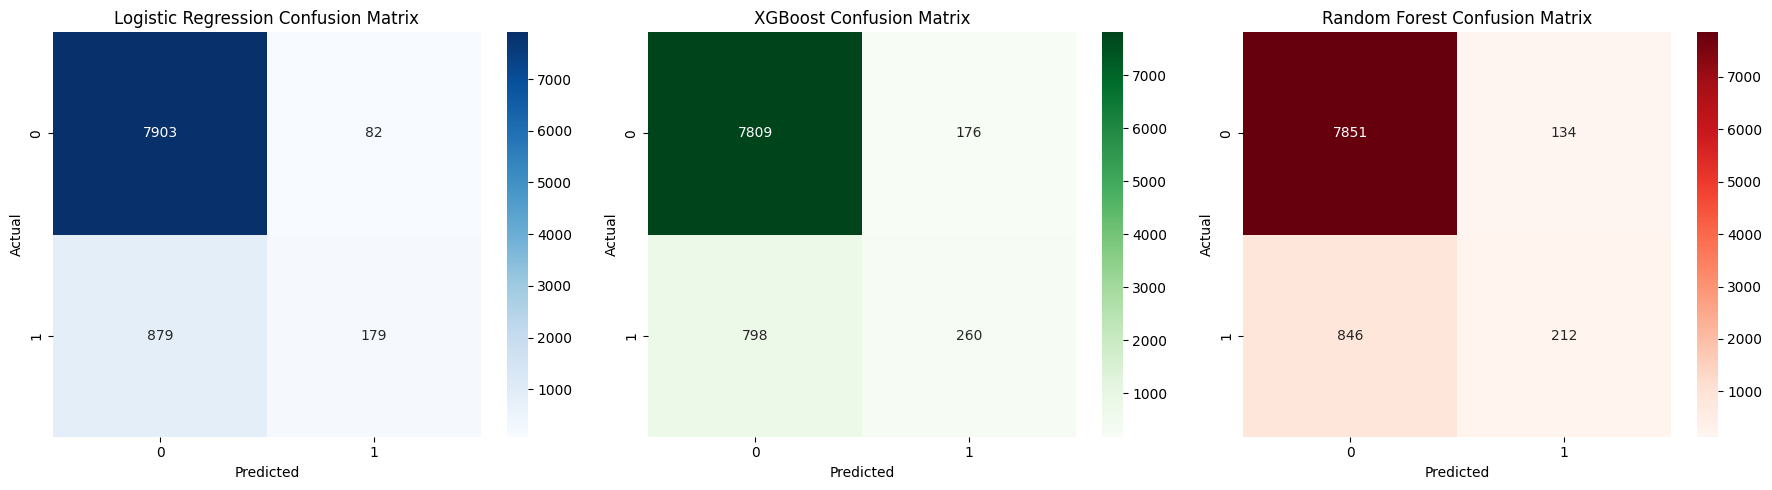

In [7]:
# Compare models
models_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost', 'Random Forest'],
    'Accuracy': [lr_accuracy, xgb_accuracy, rf_accuracy],
    'ROC AUC': [lr_roc_auc, xgb_roc_auc, rf_roc_auc],
    'Precision (Class 1)': [lr_report['1']['precision'], xgb_report['1']['precision'], rf_report['1']['precision']],
    'Recall (Class 1)': [lr_report['1']['recall'], xgb_report['1']['recall'], rf_report['1']['recall']],
    'F1-Score (Class 1)': [lr_report['1']['f1-score'], xgb_report['1']['f1-score'], rf_report['1']['f1-score']]
})

print("Models Comparison:")
print(models_comparison)

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Logistic Regression
cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# XGBoost
cm_xgb = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm_xgb, annot=True, fmt='d', ax=axes[1], cmap='Greens')
axes[1].set_title('XGBoost Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# Random Forest
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', ax=axes[2], cmap='Reds')
axes[2].set_title('Random Forest Confusion Matrix')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 8. Visualize Results

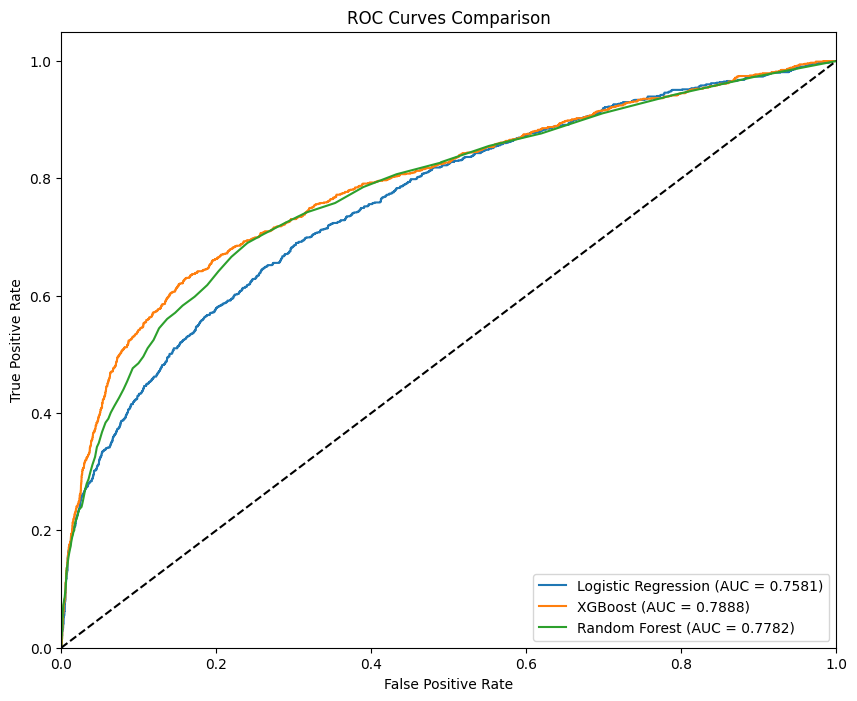

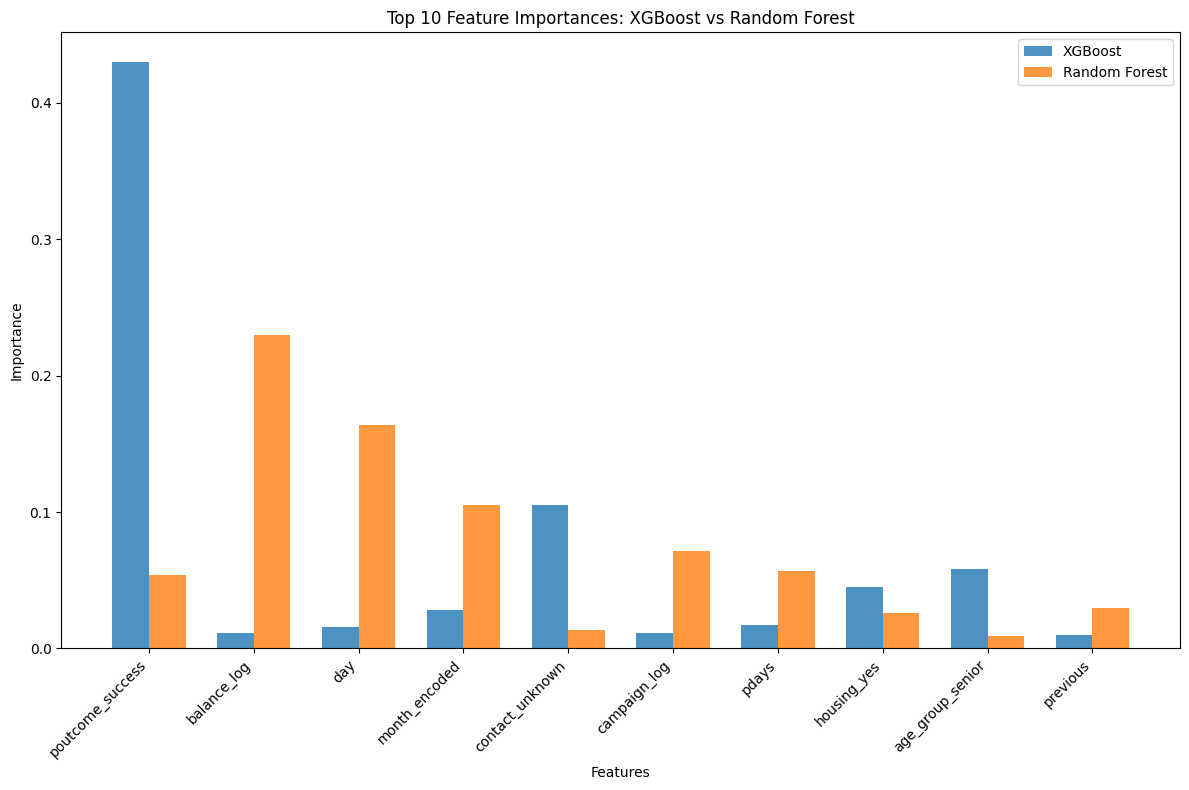

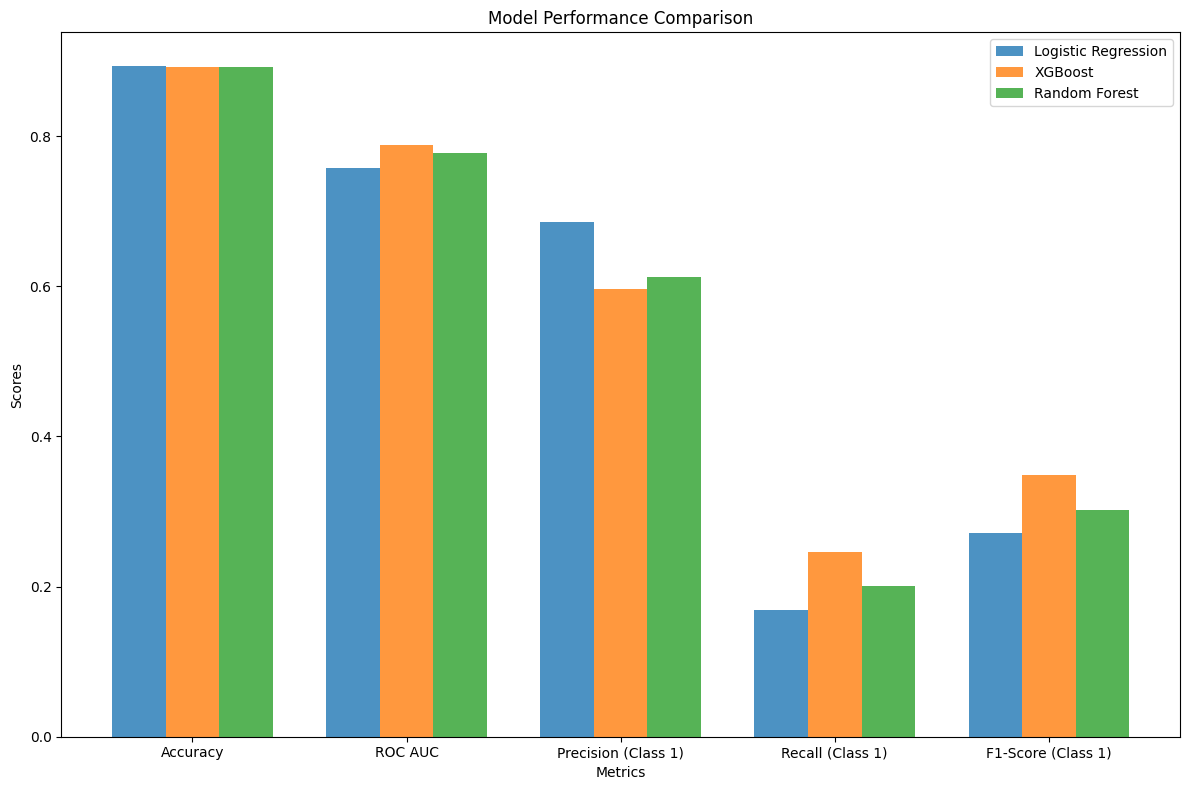

In [8]:
# ROC Curves
plt.figure(figsize=(10, 8))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_pred_proba)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {lr_roc_auc:.4f})')

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_pred_proba)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {xgb_roc_auc:.4f})')

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_pred_proba)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {rf_roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc="lower right")
plt.show()

# Feature Importance Comparison
feature_names = X.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'XGBoost': xgb_feature_importance,
    'Random Forest': rf_feature_importance
})

# Get top 10 features by average importance
importance_df['Average'] = (importance_df['XGBoost'] + importance_df['Random Forest']) / 2
top_features = importance_df.nlargest(10, 'Average')

plt.figure(figsize=(12, 8))
x = np.arange(len(top_features))
width = 0.35

plt.bar(x - width/2, top_features['XGBoost'], width, label='XGBoost', alpha=0.8)
plt.bar(x + width/2, top_features['Random Forest'], width, label='Random Forest', alpha=0.8)

plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Top 10 Feature Importances: XGBoost vs Random Forest')
plt.xticks(x, top_features['Feature'], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# Model Performance Bar Chart
metrics = ['Accuracy', 'ROC AUC', 'Precision (Class 1)', 'Recall (Class 1)', 'F1-Score (Class 1)']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 8))
rects1 = ax.bar(x - width, models_comparison.loc[0, metrics], width, label='Logistic Regression', alpha=0.8)
rects2 = ax.bar(x, models_comparison.loc[1, metrics], width, label='XGBoost', alpha=0.8)
rects3 = ax.bar(x + width, models_comparison.loc[2, metrics], width, label='Random Forest', alpha=0.8)

ax.set_xlabel('Metrics')
ax.set_ylabel('Scores')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

plt.tight_layout()
plt.show()